# 05. LLM 챗봇 만들기

---

## 이번 실습 목표

LangGraph와 `ChatOpenAI`를 결합해 **LLM 챗봇 그래프**를 만든다.

이번 실습에서 다루는 핵심은 다음과 같다.

| 구분            | 내용                                                          |
| --------------- | ------------------------------------------------------------- |
| 기본 챗봇       | `MessagesState`를 사용해 사용자 메시지를 LLM에 전달한다.      |
| 시스템 프롬프트 | `SystemMessage`로 챗봇의 역할과 응답 방식을 제어한다.         |
| 멀티턴 대화     | 이전 메시지를 직접 누적해 문맥을 유지한다.                    |
| 스트리밍        | `stream_mode="messages"`로 LLM 토큰을 실시간 출력한다.        |
| 조건부 분기     | 사용자 질문 수준에 따라 전문가 모드와 입문자 모드로 분기한다. |

---

## 핵심: `MessagesState`

`MessagesState`는 LangGraph에서 대화 메시지를 다룰 때 자주 사용하는 prebuilt State이다.

```python
from langgraph.graph import MessagesState
```

개념적으로는 다음과 같은 구조로 이해하면 된다.

```python
# 개념적 구조
class MessagesState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
```

즉, `messages` 필드는 일반 리스트처럼 완전히 덮어써지는 것이 아니라,  
새 메시지가 들어오면 기존 메시지 뒤에 누적된다.

---


## 주의: 이 실습의 대화 기억 방식

이번 실습은 멀티턴 대화는 **checkpointer 기반 영속 메모리**가 아니다.
여기서는 다음 방식으로 문맥을 유지한다.

```text
이전 HumanMessage + 이전 AIMessage + 새 HumanMessage
    ↓
다시 app.invoke()에 전달
```

즉, 이전 대화 내용을 `messages` 리스트에 직접 누적해 다음 호출에 넣는 방식이다.  
실제 서비스에서는 `checkpointer` 또는 DB를 사용해 세션별 대화 상태를 저장할 수 있다.


## 환경 변수 로딩


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv(override=True, dotenv_path="../.env")
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(
        "OPENAI_API_KEY가 설정되어 있지 않습니다. .env 파일에 OPENAI_API_KEY를 추가하세요."
    )

## 그래프 그리기


In [ ]:
from IPython.display import Image, display


def show_graph(app) -> None:
    """LangGraph 그래프를 이미지로 출력하고, 실패하면 ASCII 그래프로 대체한다."""
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())

---

## 1. 가장 단순한 챗봇

노드 하나짜리 챗봇을 만든다.

실행 흐름은 다음과 같다.

```text
START → 챗봇 노드 → END
```

`챗봇 노드`는 현재 `messages`를 LLM에 전달하고, LLM 응답을 다시 `messages`에 추가한다.


/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_26102/3915651890.py:9: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  llm = ChatNVIDIA(


LLM 준비 완료


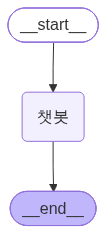

In [12]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_nvidia_ai_endpoints import ChatNVIDIA

API_KEY = os.getenv("NVIDIA")
MODEL = os.getenv("NVIDIA_MODEL")

llm = ChatNVIDIA(
    model=MODEL, api_key=API_KEY, temperature=0.7, timeout=600, max_tokens=4096
)
print("LLM 준비 완료")


def chatbot_node(state: MessagesState) -> dict:
    """사용자 메시지를 LLM에 전달하고 AI 응답을 State에 추가한다."""

    # state["messages"]에는 HumanMessage, AIMessage 등 대화 메시지들이 들어 있다.
    # 가장 단순한 챗봇에서는 현재 messages 전체를 그대로 LLM에 전달한다.
    response = llm.invoke(state["messages"])
    print("response : ", response)
    # MessagesState의 messages 필드는 add_messages reducer가 적용되어 있다.
    # 따라서 {"messages": [response]}를 반환하면 기존 messages 뒤에 AI 응답이 추가된다.
    return {"messages": [response]}


# 1) 챗봇 노드를 StateGraph에 추가한다.
builder = StateGraph(MessagesState)

# 2) 챗봇 역할을 수행할 노드를 등록한다.
builder.add_node("챗봇", chatbot_node)

# 3) START -> 챗봇 -> END 형태로 그래프를 구성한다.
builder.add_edge(START, "챗봇")
builder.add_edge("챗봇", END)

# 4) 그래프를 컴파일하여 실행 가능한 형태로 만든다.
app = builder.compile()

try:
    show_graph(app)
except:
    print(app.get_graph().draw_ascii())

### 단일 질문 테스트


In [13]:
# 단일 질문 테스트
result = app.invoke(
    {"messages": [HumanMessage(content="파이썬이 뭔가요? 한 문장으로 설명해줘.")]}
)

print("\n[응답]")
print(result["messages"][-1].content)

response :  content='파이썬은 간결하고 직관적인 문법과 풍부한 표준 라이브러리를 갖춘 고수준 프로그래밍 언어입니다.' additional_kwargs={'reasoning_content': 'User wants: "파이썬이 뭔가요? 한 문장으로 설명해줘." Means: "What is Python? Explain in one sentence." Provide a concise sentence. Also maybe Korean language. Provide a single sentence describing Python. Let\'s respond in Korean. The sentence: "파이썬은 동적 타이핑과 가독성 높은 문법을 갖춘 고수준 프로그래밍 언어입니다." Or "파이썬은 간결하고 직관적인 문법으로 다양한 분야에 쓰이는 고수준 프로그래밍 언어입니다." Provide one sentence. Should be correct.', 'reasoning': 'User wants: "파이썬이 뭔가요? 한 문장으로 설명해줘." Means: "What is Python? Explain in one sentence." Provide a concise sentence. Also maybe Korean language. Provide a single sentence describing Python. Let\'s respond in Korean. The sentence: "파이썬은 동적 타이핑과 가독성 높은 문법을 갖춘 고수준 프로그래밍 언어입니다." Or "파이썬은 간결하고 직관적인 문법으로 다양한 분야에 쓰이는 고수준 프로그래밍 언어입니다." Provide one sentence. Should be correct.', '_reasoning_api_fields': ['reasoning_content', 'reasoning']} response_metadata={'role': 'assistant', 'content': '파이썬은 간결하고 직관적인 

In [9]:
question = {
    "messages": [HumanMessage(content="파이썬이 뭔가요? 한 문장으로 설명해줘.")]
}
for step in app.stream(question):
    print(step)

{'챗봇': {'messages': [AIMessage(content='파이썬은 배우기 쉽고, 다양한 분야(웹, 데이터 과학, 인공지능 등)에서 활용되는 범용 프로그래밍 언어입니다.', additional_kwargs={'reasoning_content': 'The user asks in Korean: "파이썬이 뭔가요? 한 문장으로 설명해줘." They want a one-sentence explanation of Python. I should answer in Korean presumably. Provide a concise explanation: "파이썬은 배우기 쉽고, 다양한 분야에서 활용되는 범용 프로그래밍 언어입니다." That\'s one sentence. That should be fine.', 'reasoning': 'The user asks in Korean: "파이썬이 뭔가요? 한 문장으로 설명해줘." They want a one-sentence explanation of Python. I should answer in Korean presumably. Provide a concise explanation: "파이썬은 배우기 쉽고, 다양한 분야에서 활용되는 범용 프로그래밍 언어입니다." That\'s one sentence. That should be fine.', '_reasoning_api_fields': ['reasoning_content', 'reasoning']}, response_metadata={'role': 'assistant', 'content': '파이썬은 배우기 쉽고, 다양한 분야(웹, 데이터 과학, 인공지능 등)에서 활용되는 범용 프로그래밍 언어입니다.', 'refusal': None, 'annotations': None, 'audio': None, 'function_call': None, 'tool_calls': [], 'reasoning': 'The user asks in Korean: "파이썬이 뭔가요? 한 문장으

---

## 2. 시스템 프롬프트 추가

`SystemMessage`는 LLM에게 역할, 응답 기준, 말투를 지정할 때 사용한다.

여기서는 챗봇을 **파이썬 튜터**로 설정한다.

중요한 점은 다음과 같다.

```text
SystemMessage + 기존 대화 messages
    ↓
LLM 호출
    ↓
AIMessage만 State에 추가
```

즉, 시스템 프롬프트는 LLM 호출 시 앞에 붙여 사용하되,  
반환 State에는 AI 응답만 추가한다.


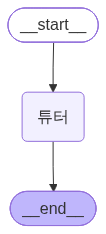

In [ ]:
SYSTEM_PROMPT = """당신은 친절한 파이썬 튜터입니다.
- 초보자도 이해할 수 있게 쉽게 설명하세요
- 핵심만 간결하게 답변하세요
- 예시 코드는 짧게 보여주세요"""


def tutor_node(state: MessagesState) -> dict:
    # SystemMessage는 LLM 호출용 컨텍스트로만 사용한다.
    # state["messages"] 앞에 붙이면 LLM은 이 역할을 기준으로 답변한다.
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]

    response = llm.invoke(messages)

    # 시스템 프롬프트는 State에 누적하지 않고, AI 응답만 messages에 추가한다.
    return {"messages": [response]}


# 1) 챗봇 노드를 StateGraph에 추가한다
builder = StateGraph(MessagesState)

# 2) 챗봇 역할을 수행할 노드를 등록한다
builder.add_node("튜터", tutor_node)

# 3) START -> 챗봇 -> END 형태로 그래프를 구성한다
builder.add_edge(START, "튜터")
builder.add_edge("튜터", END)

# 4) 그래프를 컴파일하여 실행 가능한 형태로 만든다
app2 = builder.compile()

try:
    show_graph(app2)
except:
    print(app2.get_graph().draw_ascii())

In [11]:
# 질문 테스트
result = app2.invoke(
    {"messages": [HumanMessage(content="리스트와 튜플의 차이가 뭔가요?")]}
)
print(result["messages"][-1].content)

### 리스트(`list`) vs 튜플(`tuple`)

|   | 리스트 | 튜플 |
|---|--------|------|
| **가변성** | **가변**: 만들고 나서도 `append`, `remove` 등으로 변형 가능 | **불변**: 한 번 만들면 내용이 바뀌지 않음 |
| **사용 목적** | 데이터가 자주 바뀌거나 길이를 동적으로 조정해야 할 때 | 데이터가 고정돼 있을 때, 가독성 좋게 묶어 두고 싶을 때 |
| **문자법** | 대괄호 `[]` | 소괄호 `()` 또는 괄호 없이 쉼표만 |
| **메모리** | 약간 더 차지 | `tuple`이 내부적으로 더 작은 메모리를 사용 |
| **속도** | 삽입·삭제 시 느림 | 불변이므로 조회가 더 빠름 |

#### 예시 코드

```python
# 리스트 예시
fruits = ['apple', 'banana']
fruits.append('cherry')     # 추가 가능
print(fruits)  # ['apple', 'banana', 'cherry']

# 튜플 예시
coords = (10, 20)
# coords[0] = 30   # ❌ 오류! 튜플은 수정 불가
print(coords)  # (10, 20)
```

> **핵심**  
> - 리스트는 *가변* → 동적으로 바꿀 수 있음  
> - 튜플은 *불변* → 한 번 만든 뒤 내용이 바뀌지 않음  
> 따라서 데이터가 변할 필요가 없으면 튜플을 쓰고, 변할 수 있으면 리스트를 쓰면 됩니다.


In [14]:
for step in app2.stream(
    {"messages": [HumanMessage(content="리스트와 튜플의 차이가 뭔가요?")]}
):
    print(step)

{'튜터': {'messages': [AIMessage(content="### 리스트(`list`) vs 튜플(`tuple`)\n\n| 구분 | 리스트 | 튜플 |\n|------|--------|------|\n| **문법** | `[]` | `()` |\n| **가변성** | **변경 가능** (append, remove 등) | **불변** (한 번 만들면 수정 불가) |\n| **사용 예** | 데이터가 자주 바뀌는 경우 | 값이 변하지 않을 때, 혹은 해시가 필요할 때 (딕셔너리 키 등) |\n| **속도** | 조금 느림 (메모리 할당/해제) | 조금 빠름 (불변 객체라 캐시 가능) |\n| **안전성** | 변경이 자유로워 실수 위험 | 안정적 (오류 방지) |\n\n---\n\n#### 예시\n\n```python\n# 리스트\nnumbers = [1, 2, 3]\nnumbers.append(4)        # 변경 가능\nnumbers[0] = 10\n\n# 튜플\ncoords = (10, 20)\n# coords[0] = 5    # ❌ TypeError: 'tuple' object does not support item assignment\n```\n\n---\n\n#### 언제 쓰나요?\n\n- **리스트**  \n  - `append()`, `pop()`, `sort()` 등으로 자주 수정할 때  \n  - 데이터가 동적으로 변할 수 있는 경우\n\n- **튜플**  \n  - 값이 변하지 않아야 할 때 (예: 좌표, 설정 값)  \n  - 딕셔너리 키로 사용하거나, `hash()`가 필요할 때  \n  - 메모리 사용량을 조금 더 줄이고 싶을 때\n\n---\n\n> **핵심**  \n> **리스트는 가변, 튜플은 불변**이라 기억하면 됩니다.  \n> 필요에 따라 두 자료형을 골라 쓰면 됩니다.", additional_kwargs={'reasoning_content': 'We must answer in Korean. Provide 

---

## 3. 멀티턴 대화 (대화 기록 유지)

이 예제에서는 이전 대화를 `messages` 리스트에 직접 누적해 문맥을 유지한다.

```text
1턴 입력: [HumanMessage("내 이름은 민준이에요.")]
1턴 결과: [HumanMessage(...), AIMessage(...)]

2턴 입력: [HumanMessage(...), AIMessage(...), HumanMessage("딕셔너리가 뭔가요?")]
2턴 결과: [HumanMessage(...), AIMessage(...), HumanMessage(...), AIMessage(...)]
```

이 방식은 수업용으로 이해하기 쉽다.  
다만 실제 서비스에서 여러 사용자와 여러 세션을 관리하려면 checkpointer 또는 DB 저장 구조가 필요하다.


In [15]:
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage


def chat_session(app, questions: list[str], system: str = "") -> list[BaseMessage]:
    """여러 질문을 순서대로 실행하면서 messages를 직접 누적한다."""
    messages: list[BaseMessage] = []

    print("=" * 55)
    for i, question in enumerate(questions, 1):
        # 1) 새 사용자 질문을 messages에 추가한다
        messages.append(HumanMessage(content=question))

        # 2) 지금까지의 전체 대화 기록을 그래프에 전달하여 응답을 받는다
        result = app.invoke({"messages": messages})

        # 3) LangGraph 노드에서 반환된 AI 응답을 messages에 추가한다
        messages = result["messages"]  # 전체 대화 기록을 업데이트

        # 4) 이번 턴의 AI 응답을 출력한다
        ai_response = result["messages"][-1]

        print(f"[{i}] 사용자: {question}")
        print(f"     AI    : {ai_response.content}")
        print("-" * 55)

    return messages

In [16]:
# 3턴 대화 - 이전 대화를 기억하는지 확인
conversion = chat_session(
    app2,
    questions=[
        "내 이름은 민준이에요.",
        "파이썬 딕셔너리가 뭔가요?",
        "제 이름이 뭐라고 했죠?",  # 문맥 기억 테스트
    ],
)

[1] 사용자: 내 이름은 민준이에요.
     AI    : 안녕하세요, 민준님!  
Python에 대해 궁금한 점이 있나요? 예를 들어, 기본 문법, 변수, 함수, 혹은 다른 주제에 대해 배우고 싶으신가요? 알려주시면 바로 도와드릴게요!
-------------------------------------------------------
[2] 사용자: 파이썬 딕셔너리가 뭔가요?
     AI    : ## 파이썬 딕셔너리란?

- **키(key) → 값(value)** 쌍으로 데이터를 저장하는 자료형입니다.  
- 마치 사전(단어 → 뜻)처럼 “이름” → “나이”처럼, **키**를 통해 **값**에 바로 접근할 수 있어요.

### 핵심 포인트

| 개념 | 설명 |
|------|------|
| **키** | 문자열, 숫자, 튜플 등 불변(immutable) 객체만 사용 |
| **값** | 문자열, 숫자, 리스트, 또 다른 딕셔너리 등 무엇이든 가능 |
| **문법** | `{키: 값, 키: 값, ...}` |
| **접근** | `dict[키]` 로 값 조회, `dict[키] = 값` 으로 수정/추가 |
| **반복** | `for key in dict:` → 키 순회, `dict.items()` → 키·값 쌍 순회 |

### 짧은 예시

```python
# 딕셔너리 만들기
person = {
    "name": "민준",
    "age": 25,
    "hobbies": ["코딩", "음악"]
}

# 값 조회
print(person["name"])   # 민준

# 값 수정
person["age"] = 26

# 새로운 키·값 추가
person["city"] = "서울"

# 반복
for key, value in person.items():
    print(f"{key}: {value}")
```

출력은

```
name: 민준
age: 26
hobbies: ['코딩', '음악']
city: 서울
```

딕셔너리는 **검색이 빠르고

In [ ]:
conversion

[HumanMessage(content='내 이름은 민준이에요.', additional_kwargs={}, response_metadata={}, id='a2d19cf9-ce81-4c5e-a2b9-1ec75c50078b'),
 AIMessage(content='안녕하세요, 민준님! 파이썬에 대해 궁금한 점이 있으신가요? 어떤 도움이 필요하신지 말씀해 주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 68, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_800187fee2', 'id': 'chatcmpl-DpGj7rJQVaZ3udb4ErkUcE7vh3T4X', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eb283-181c-7ec1-9c3e-77978cf8ab24-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 33, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

---

## 4. 스트리밍 응답

`stream()`을 사용하면 그래프 실행 중 발생하는 출력을 단계적으로 받을 수 있다.

여기서는 `stream_mode="messages"`를 사용한다.
이 모드는 LLM이 생성하는 메시지 조각을 토큰 단위로 출력할 때 사용한다.

```python
for chunk, metadata in app.stream(..., stream_mode="messages"):
    ...
```

`metadata`에는 어떤 노드에서 생성된 토큰인지 등 실행 관련 정보가 함께 들어올 수 있다.


In [ ]:
# stream_mode="messages"로 토큰 단위 스트리밍
print("[스트리밍 응답]")
print("-" * 40)

for chunk, metadata in app2.stream(
    {"messages": [HumanMessage(content="파이썬 for 루프를 간단히 설명해줘")]},
    stream_mode="messages",
):
    # stream_mode="messages"에서는 LLM 토근 조각과 메타데이터를 반환한다.
    # chunk.content에는 토큰 조각이 들어 있는지 판단함
    if hasattr(chunk, "content") and chunk.content:
        print(chunk.content, end="", flush=True)

print("\n" + "-" * 40)


[스트리밍 응답]
----------------------------------------
`for` 루프는 반복문으로, 리스트나 문자열 같은 반복 가능한 객체의 각 요소에 대해 코드를 실행할 수 있게 해줍니다. 

### 기본 구조
```python
for 요소 in 반복가능한객체:
    # 실행할 코드
```

### 예시
리스트의 각 숫자를 출력하는 예시입니다.
```python
numbers = [1, 2, 3]
for num in numbers:
    print(num)
```
이 코드는 1, 2, 3을 각각 출력합니다. `for` 루프는 리스트의 각 요소를 순서대로 가져와서 코드 블록을 실행합니다.
----------------------------------------


---

## 5. 조건부 Edge를 활용한 챗봇 (간단한 분기)

사용자 입력에 따라 다음 두 가지 모드로 분기한다.

| 모드        | 조건                                                 | 실행 노드  |
| ----------- | ---------------------------------------------------- | ---------- |
| 전문가 모드 | 질문에 `전문`, `심화`, `내부`, `CPython` 등이 포함됨 | `전문가봇` |
| 입문자 모드 | 그 외 일반 질문                                      | `입문자봇` |

이번 예제에서는 `MessagesState`를 확장해 `level` 필드를 추가한다.

```python
class RoutedChatState(MessagesState):
    level: NotRequired[str]
```

이렇게 하면 `messages`는 계속 누적하면서, 중간 판단 결과인 `level`도 State에 저장할 수 있다.


In [3]:
import os
from dotenv import load_dotenv
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from typing import NotRequired, Literal
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage

API_KEY = os.getenv("NVIDIA")
MODEL = os.getenv("NVIDIA_MODEL")

llm = ChatNVIDIA(model=MODEL, api_key=API_KEY, timeout=600, max_tokens=2048)


EXPERT_SYSTEM = "당신은 파이썬 전문가입니다. 기술적으로 정확하고 심층적으로 답변하세요."
BEGINNER_SYSTEM = "당신은 파이썬 입문자 튜터입니다. 비유와 쉬운 언어로 설명하세요."


# MessagesState를 상속 받아서 State의 재정의 함
class RoutedChatState(MessagesState):
    """messages에 분기 판단 결과(level)를 추가한 State이다."""

    # NotRequired를 사용하면 초기 입력에 level key가 없어도 된다.
    # level은 detect_level 노드가 실행된 뒤 State에 추가된다.
    level: NotRequired[str]


def detect_level(state: RoutedChatState) -> dict:
    """마지막 사용자 메시지를 보고 전문가/입문자 수준을 판단한다."""

    last_message = state["messages"][-1].content

    expert_keywords = ["전문", "심화", "내부", "CPython", "GIL", "메모리"]

    level = (
        "expert"
        if any(keyword in last_message for keyword in expert_keywords)
        else "beginner"
    )

    print(f"  [레벨감지] '{last_message[:25]}...' → {level}")

    # 중요:
    # MessagesState에서 messages를 그대로 반환하면 메시지가 중복 누적될 수 있다.
    # 따라서 여기서는 messages를 반환하지 않고, 새로 계산한 level만 반환한다.
    return {"level": level}


def expert_bot(state: RoutedChatState) -> dict:
    """전문가 수준의 시스템 프롬프트를 적용해 응답한다."""

    messages_for_llm = [SystemMessage(content=EXPERT_SYSTEM)] + state["messages"]
    print("llm 호출 준비")
    response = llm.invoke(messages_for_llm)
    print("llm 작업 완료")
    return {"messages": [response]}


def beginner_bot(state: RoutedChatState) -> dict:
    """입문자 수준의 시스템 프롬프트를 적용해 응답한다."""

    messages_for_llm = [SystemMessage(content=BEGINNER_SYSTEM)] + state["messages"]
    response = llm.invoke(messages_for_llm)
    return {"messages": [response]}


def route_level(state: RoutedChatState) -> Literal["expert", "beginner"]:
    """detect_level 노드가 저장한 level 값에 따라 다음 경로를 선택한다."""

    return state["level"]


builder = StateGraph(RoutedChatState)

builder.add_node("레벨감지", detect_level)
builder.add_node("전문가봇", expert_bot)
builder.add_node("입문자봇", beginner_bot)

builder.add_edge(START, "레벨감지")

# path_map을 명시하면 라우팅 함수의 반환값과 실제 노드명을 분리할 수 있다.
# 또한 그래프 시각화에서 가능한 분기 대상이 명확하게 표시된다.
builder.add_conditional_edges(
    "레벨감지",
    route_level,
    {
        "expert": "전문가봇",
        "beginner": "입문자봇",
    },
)

builder.add_edge("전문가봇", END)
builder.add_edge("입문자봇", END)

app3 = builder.compile()

/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_31178/201101498.py:11: DeprecationWarning: The 'max_tokens' parameter is deprecated and will be removed in a future version. Please use 'max_completion_tokens' instead.
  llm = ChatNVIDIA(model=MODEL, api_key=API_KEY, timeout=600, max_tokens=2048)


### 레벨별 응답 차이 비교


In [4]:
# 레벨별 응답 차이 비교
questions = [
    "파이썬 GIL이 뭔가요? 전문가 수준으로 설명해줘",  # → 전문가 모드
    "파이썬 함수가 뭔가요?",  # → 입문자 모드
]

for q in questions:
    print(f"\n[질문] {q}")
    print("-" * 50)
    r = app3.invoke({"messages": [HumanMessage(content=q)]})
    print(r["messages"][-1].content[:300])  # 처음 300자만 출력


[질문] 파이썬 GIL이 뭔가요? 전문가 수준으로 설명해줘
--------------------------------------------------
  [레벨감지] '파이썬 GIL이 뭔가요? 전문가 수준으로 설명...' → expert
llm 호출 준비
llm 작업 완료


[질문] 파이썬 함수가 뭔가요?
--------------------------------------------------
  [레벨감지] '파이썬 함수가 뭔가요?...' → beginner
## 파이썬 함수란?  
쉽게 말하면 **“작은 프로그램 모듈”**입니다.  

---

### 1. 함수는 무엇일까요?  
- **원형**: 파이썬에서 **함수**는 한 번 정의해두면, 어디서든 “호출(call)”해서 재사용할 수 있는 코드 블록입니다.  
- **비유**:   
  - **레시피**: 요리 책에 적힌 ‘스파게티 소스 만들기’ 같은 절차입니다.  
  - **전기 라면 기계**: “전기(문자)”가 눌리면 램프가 켜지고, 물이 끓고, 라면이 나옵니다.  
  - **계산기**: ‘더하기’ 버튼을 누르면 두 수의 합을


In [ ]:
q = "파이썬 GIL이 뭔가요? 전문가 수준으로 설명해줘"
for step in app3.stream({"messages": [HumanMessage(content=q)]}):
    print("-" * 10)
    print(step)

  [레벨감지] '파이썬 GIL이 뭔가요? 전문가 수준으로 설명...' → expert
----------
{'레벨감지': {'level': 'expert'}}
----------
{'전문가봇': {'messages': [AIMessage(content='GIL(전역 인터프리터 락, Global Interpreter Lock)은 CPython(파이썬의 가장 널리 사용되는 구현체)에서 멀티스레딩 환경에서의 메모리 관리를 용이하게 하기 위해 도입된 메커니즘입니다. GIL은 한 번에 하나의 스레드만 Python 바이트코드를 실행할 수 있도록 제한함으로써, 여러 스레드가 동시에 Python 객체에 접근할 때 발생할 수 있는 데이터 경합 문제를 방지합니다.\n\n### GIL의 동작 원리\n\n1. **Locking Mechanism**: GIL은 CPython 인터프리터의 실행 과정에서 바이트코드를 해석하는 동안 스레드 간에 상호 배제를 보장합니다. 즉, GIL이 활성화된 상태에서는 한 스레드가 Python 코드를 실행하는 동안 다른 스레드는 대기해야 합니다. \n\n2. **스레드 스위칭**: CPython은 스레드 전환을 일정한 시간 간격으로 수행합니다. GIL은 이 시간 간격이 지나면 현재 실행 중인 스레드의 실행을 중단하고 다른 스레드에게 CPU를 할당합니다. 이 방식은 CPU 바운드 작업에서 성능 저하를 일으킬 수 있습니다.\n\n3. **I/O 바운드 작업**: I/O 작업(파일 읽기/쓰기, 네트워크 요청 등)에서는 GIL이 상대적으로 무의미할 수 있습니다. I/O 작업이 진행되는 동안 GIL이 해제되고 다른 스레드가 실행될 수 있기 때문에, GIL은 I/O 바운드 작업에서는 큰 성능 저하를 초래하지 않습니다.\n\n### GIL의 장점과 단점\n\n#### 장점:\n- **데이터 안전성**: GIL은 메모리 관리와 객체의 참조 카운트를 간편하게 처리할 수 있게 하여, 여러 스레드가 동일한 데이터를 동시에 수정할 때 발생할 수 있는 문제를 예방합니다. 이는

---

## 정리

```python
# LangGraph 챗봇 기본 패턴

from langgraph.graph import MessagesState

def chatbot_node(state: MessagesState) -> dict:
    response = llm.invoke(state["messages"])
    return {"messages": [response]}  # 기존 messages 뒤에 AIMessage가 누적됨

builder = StateGraph(MessagesState)
builder.add_node("챗봇", chatbot_node)
builder.add_edge(START, "챗봇")
builder.add_edge("챗봇", END)

app = builder.compile()

result = app.invoke({
    "messages": [HumanMessage(content="질문")]
})
```

| 방식                             | 설명                                               |
| -------------------------------- | -------------------------------------------------- |
| `MessagesState`                  | `messages` 필드를 누적 관리하는 대화용 State       |
| `SystemMessage`                  | LLM의 역할, 응답 방식, 말투를 지정                 |
| `invoke()`                       | 그래프를 한 번 실행하고 최종 State를 반환          |
| `stream(stream_mode="messages")` | LLM 메시지 조각을 토큰 단위로 스트리밍             |
| `add_conditional_edges()`        | State에 따라 다음 노드를 선택                      |
| `path_map`                       | 라우팅 함수 반환값과 실제 노드명을 명시적으로 연결 |

## 이 실습에서 특히 주의할 점

1. `MessagesState`에서 이미 존재하는 `messages`를 그대로 반환하면 메시지가 중복 누적될 수 있다.
2. 멀티턴 문맥 유지는 이 실습에서는 `messages` 리스트를 직접 누적하는 방식이다.
3. 실제 서비스에서는 checkpointer 또는 DB를 사용해 세션별 대화 이력을 저장하는 것이 적절하다.
4. 조건부 Edge는 `path_map`을 명시하면 실행 흐름과 그래프 시각화가 더 명확하다.
